[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benjamalegni/ML-luka/blob/main/02-deep-learning/labs-fundamentos/03_CNN_MNIST_Comparativa_Dense_vs_CNN.ipynb)



# 🎯 Práctica 1: Fully Connected (Dense) vs CNN

**Objetivo:** entrenar **dos** modelos (una red *Fully Connected* y una **CNN**) sobre el dataset **MNIST** para comparar su desempeño.



## 📦 Requisitos y módulos a usar
- `tensorflow` y `keras` (modelos `Sequential`, capas `Dense`, `Conv2D`, `MaxPooling2D`, `Flatten`)  
- `numpy` para operaciones numéricas  
- `scikit-learn` para la matriz de confusión  
- `matplotlib` para graficar ejemplos y la matriz (sin estilos ni colores específicos)


In [1]:
# %% Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# (Opcional) reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)


## 📊 Dataset: MNIST

El **dataset MNIST** contiene **70.000 imágenes de dígitos (0–9)** en **28×28 píxeles en escala de grises**. Se divide en **60.000 imagenes de entrenamiento** y **10.000 de prueba**.

Lo primero que hacemos es descargar MNIST desde `tf.keras.datasets`, normalizamos en rango `[0,1]` y preparamos **dos** vistas de los datos:

- **Fully Connected (FC):** aplanado a vectores de longitud 784 (`28×28`)  
- **CNN:** agregamos un canal y mantenemos la forma `(28, 28, 1)`


In [2]:
# %% 1) Carga de MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalización
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

num_classes = 10

# Versiones para cada modelo
x_train_fc = x_train.reshape((-1, 28*28))       # (n, 784)
x_test_fc  = x_test.reshape((-1, 28*28))

x_train_cnn = x_train[..., np.newaxis]          # (n, 28, 28, 1)
x_test_cnn  = x_test[...,  np.newaxis]

print("Shapes ->")
print("  x_train_fc :", x_train_fc.shape, "  x_test_fc :", x_test_fc.shape)
print("  x_train_cnn:", x_train_cnn.shape, " x_test_cnn:", x_test_cnn.shape)
print("  y_train    :", y_train.shape,      "     y_test:", y_test.shape)


Shapes ->
  x_train_fc : (60000, 784)   x_test_fc : (10000, 784)
  x_train_cnn: (60000, 28, 28, 1)  x_test_cnn: (10000, 28, 28, 1)
  y_train    : (60000,)      y_test: (10000,)


## ⚙️  Creación de datasets eficientes con `tf.data`

En TensorFlow utilizamos `tf.data.Dataset` para preparar los datos antes del entrenamiento de forma optimizada:

- **`from_tensor_slices`**: toma los datos y los separa en ejemplos individuales, emparejando cada entrada con su etiqueta.   
- **`shuffle(10000)`**: mezcla aleatoriamente los datos para evitar patrones en el entrenamiento.  
- **`batch(batch_size)`**: agrupa ejemplos en mini-lotes (aquí de 128 muestras) para entrenar de manera más eficiente.  
- **`prefetch(tf.data.AUTOTUNE)`**: permite que el preprocesamiento y el entrenamiento se ejecuten en paralelo, acelerando el pipeline.  

👉 Se construyen datasets separados para las versiones *fully connected* (`train_ds_fc`, `test_ds_fc`) y *convolucional* (`train_ds_cnn`, `test_ds_cnn`).


In [3]:
# %% 2) Datasets eficientes
batch_size = 128
train_ds_fc  = tf.data.Dataset.from_tensor_slices((x_train_fc,  y_train)).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds_fc   = tf.data.Dataset.from_tensor_slices((x_test_fc,   y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
train_ds_cnn = tf.data.Dataset.from_tensor_slices((x_train_cnn, y_train)).shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds_cnn  = tf.data.Dataset.from_tensor_slices((x_test_cnn,  y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)



## 👀 Observamos algunas imágenes
Visualizamos unas muestras para confirmar que los datos cargaron bien.


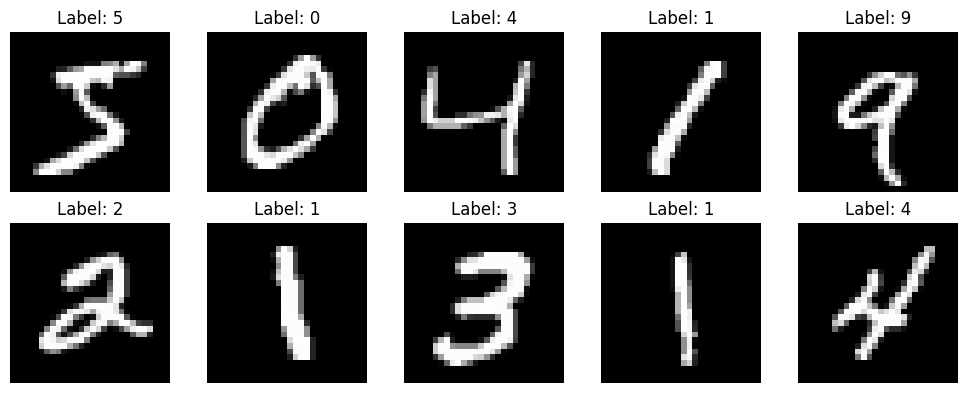

In [4]:
# %% 3) Visualización
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(x_train[i], cmap="gray")
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()



## 🧩 Modelo 1 — Fully Connected (Dense)
Arquitectura simple totalmente conectada:
- **Entrada:** vector de 784 elementos (imagen aplanada)  
- **Capas ocultas:** 256 → 128 neuronas con `ReLU`  
- **Salida:** 10 neuronas con `softmax` (probabilidades por dígito)

Compilamos con `Adam` y `sparse_categorical_crossentropy`.


In [5]:
# %% 4) Modelo FC
fc_model = Sequential([
    layers.Input(shape=(28*28,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10,  activation="softmax"),
])
fc_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fc_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)


### 🚀 Entrenamiento del modelo FC
Entrenamos pocos **epochs** para probar.


In [6]:
# %% 5) Entrenamiento FC
epochs = 5
history_fc = fc_model.fit(
    train_ds_fc,
    epochs=epochs,
    validation_data=test_ds_fc,
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9219 - loss: 0.2747 - val_accuracy: 0.9595 - val_loss: 0.1336
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9693 - loss: 0.1049 - val_accuracy: 0.9708 - val_loss: 0.0955
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9794 - loss: 0.0679 - val_accuracy: 0.9753 - val_loss: 0.0755
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9853 - loss: 0.0491 - val_accuracy: 0.9772 - val_loss: 0.0709
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9892 - loss: 0.0354 - val_accuracy: 0.9756 - val_loss: 0.0777



### ✅ Evaluación del modelo FC
Reportamos **accuracy** y calculamos la **matriz de confusión** sobre train y test.


In [7]:
# %% 6) Evaluación FC
loss_fc, acc_fc = fc_model.evaluate(test_ds_fc, verbose=0)
loss_fc_train, acc_fc_train = fc_model.evaluate(train_ds_fc, verbose=0)

print("** Fully Connected [MNIST] **")
print(f"➡️ Train Accuracy: {acc_fc_train:.4f}")
print(f"➡️ Test  Accuracy: {acc_fc:.4f}")


** Fully Connected [MNIST] **
➡️ Train Accuracy: 0.9888
➡️ Test  Accuracy: 0.9756


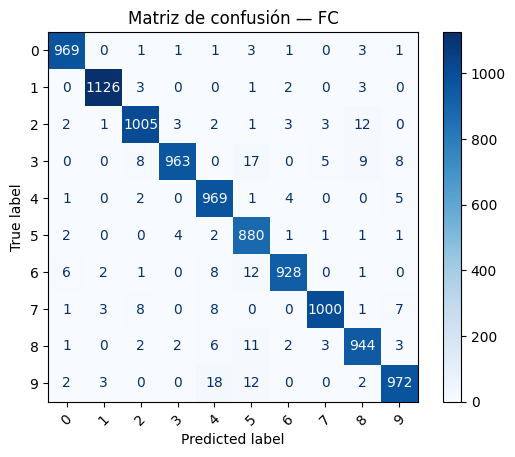

In [8]:
# Predicciones
y_pred_fc = np.argmax(fc_model.predict(test_ds_fc, verbose=0), axis=1)

# Matriz de confusión
cm_fc = confusion_matrix(y_test, y_pred_fc)

# Display con sklearn
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fc,
                              display_labels=[str(i) for i in range(10)])
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — FC")
plt.show()


## 🧱 Modelo 2 — CNN (Conv2D + MaxPooling2D)
La CNN explota la **estructura espacial** de la imagen:
- `Conv2D(32, 3)` → `MaxPooling2D(2)`  
- `Conv2D(64, 3)` → `MaxPooling2D(2)`  
- `Flatten` → `Dense(32, ReLU)` → `Dense(10, softmax)`

Misma configuración de compilación que el modelo FC.


In [9]:
# %% 7) Modelo CNN
cnn_model = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10,  activation="softmax"),
])

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,378 (274.91 KB)

 Trainable params: 70,378 (274.91 KB)

 Non-trainable params: 0 (0.00 B)


### 🚀 Entrenamiento de la CNN
Entrenamos con el mismo número de **epochs** para poder comparar.


In [10]:
epochs = 5
# %% 8) Entrenamiento CNN
history_cnn = cnn_model.fit(
    train_ds_cnn,
    epochs=epochs,
    validation_data=test_ds_cnn,
    verbose=1
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9202 - loss: 0.2735 - val_accuracy: 0.9768 - val_loss: 0.0744
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9781 - loss: 0.0715 - val_accuracy: 0.9808 - val_loss: 0.0574
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9840 - loss: 0.0515 - val_accuracy: 0.9868 - val_loss: 0.0418
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9871 - loss: 0.0423 - val_accuracy: 0.9867 - val_loss: 0.0406
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9898 - loss: 0.0337 - val_accuracy: 0.9872 - val_loss: 0.0376



### ✅ Evaluación de la CNN
Calculamos accuracy y matriz de confusión de la CNN.


In [11]:
# %% 9) Evaluación CNN
loss_cnn, acc_cnn = cnn_model.evaluate(test_ds_cnn, verbose=0)
loss_cnn_train, acc_cnn_train = cnn_model.evaluate(train_ds_cnn, verbose=0)

print("** CNN [MNIST] **")
print(f"➡️ Train Accuracy: {acc_cnn_train:.4f}")
print(f"➡️ Test  Accuracy: {acc_cnn:.4f}")


** CNN [MNIST] **
➡️ Train Accuracy: 0.9915
➡️ Test  Accuracy: 0.9872


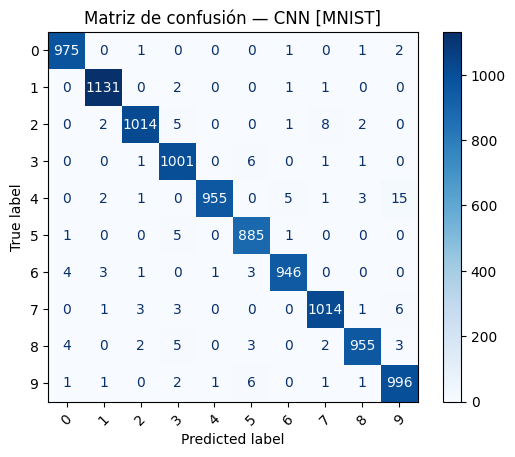

In [12]:
y_pred_cnn = np.argmax(cnn_model.predict(test_ds_cnn, verbose=0), axis=1)

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

# Display con sklearn
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn,
                              display_labels=[str(i) for i in range(10)])
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — CNN [MNIST]")
plt.show()


## 📈 Comparativa final
Mostramos las accuracies de ambos modelos. Normalmente la **CNN** supera a la **FC** en MNIST.


In [43]:
# %% 10) Resumen comparativo
print("\n================ RESUMEN ================ ")
print(f"Fully Connected — Test Accuracy: {acc_fc:.4f}")
print(f"CNN             — Test Accuracy: {acc_cnn:.4f}")
print("==========================================")



================ RESUMEN ================ 
Fully Connected — Test Accuracy: 0.9756
CNN             — Test Accuracy: 0.9872


***
# 🎯 Práctica 2: CNN para CIFAR-10

Vamos a desarrollar una CNN para un dataset un poco más desafiante que MNIST: el dataset **CIFAR-10** 

## 📊 Dataset: CIFAR-10

El **dataset CIFAR-10** contiene **60.000 imágenes en color de 32×32 píxeles** distribuidas en **10 clases** (como aviones, autos, pájaros, gatos, ciervos, perros, ranas, caballos, barcos y camiones).  
Se divide en **50.000 imágenes de entrenamiento** y **10.000 de prueba**.


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

print(tf.__version__)

2.16.2


### 📥 Carga y preparación del dataset CIFAR-10

En este paso se carga el dataset **CIFAR-10** utilizando `keras.datasets`.  

- **Carga de datos**: se obtiene un conjunto de **50.000 imágenes de entrenamiento** y **10.000 de prueba**, con sus respectivas etiquetas.  
- **Normalización**: los valores de píxeles se escalan a rango `[0,1]` dividiendo por 255.  
- **Codificación one-hot**: las etiquetas (`y_train`, `y_test`) se transforman a vectores categóricos con `to_categorical`.  
- **Dimensiones resultantes**:  
  - `c10_x_train.shape` → imágenes de entrenamiento.  
  - `c10_y_train.shape` → etiquetas de entrenamiento.  
  - `c10_x_test.shape` → imágenes de prueba.  
  - `c10_y_test.shape` → etiquetas de prueba.  

Esto deja el dataset listo para entrenar una red neuronal en una tarea de clasificación multiclase.

In [15]:
# Carga de CIFAR-10
(c10_x_train, c10_y_train), (c10_x_test, c10_y_test) = keras.datasets.cifar10.load_data()
c10_x_train = c10_x_train.astype('float32')/255.0
c10_x_test  = c10_x_test.astype('float32')/255.0

c10_num_classes = 10
c10_y_train_cat = keras.utils.to_categorical(c10_y_train, c10_num_classes)
c10_y_test_cat  = keras.utils.to_categorical(c10_y_test,  c10_num_classes)

c10_x_train.shape, c10_y_train.shape, c10_x_test.shape, c10_y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

### 🔎 Visualización de ejemplos del dataset

Definimos una función auxiliar `show_samples` que permite mostrar una grilla de imágenes seleccionadas aleatoriamente del dataset, junto con sus etiquetas.  

- **`class_names_c10`**: lista con los nombres de las 10 clases de CIFAR-10.  
- **`show_samples(x, y, class_names, n)`**:  
  - Selecciona `n` imágenes al azar.  
  - Las muestra en una cuadrícula de √n × √n.  
  - Si se pasa la lista de clases, agrega el nombre de cada categoría como título.  

Esto facilita explorar rápidamente el dataset y familiarizarse con las clases de imágenes antes de entrenar la red neuronal.

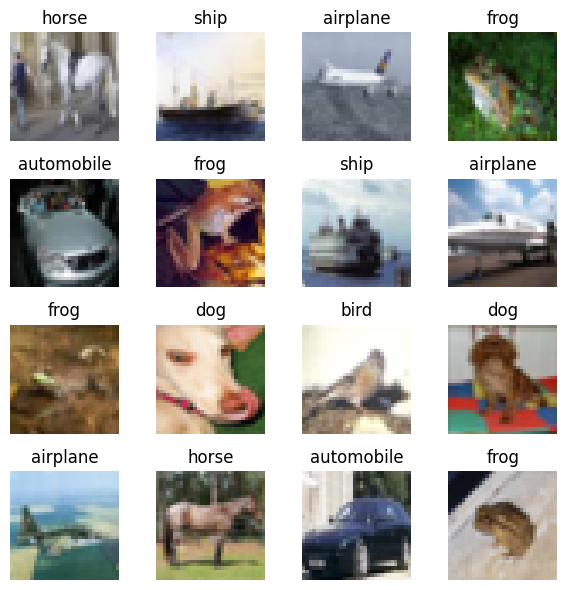

In [16]:
# Funciones para visualizar ejemplos
class_names_c10 = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

def show_samples(x, y, class_names=None, n=16):
    idx = np.random.choice(len(x), n, replace=False)
    plt.figure(figsize=(6,6))
    side = int(np.sqrt(n))
    for i, j in enumerate(idx, 1):
        plt.subplot(side, side, i)
        plt.imshow(x[j])
        plt.axis('off')
        if class_names is not None:
            plt.title(class_names[int(np.squeeze(y[j]))])
    plt.tight_layout()
    plt.show()

# Muestra de imágenes
show_samples(c10_x_train, c10_y_train, class_names_c10, n=16)

## 🧩 Arquitectura CNN para CIFAR-10

Se construye una **red neuronal convolucional (CNN)** para la tarea de clasificación en **CIFAR-10**

### Estructura del modelo
- **Entrada**: imágenes de `32×32×3` en color.  
- **Bloques convolucionales**:  
  - `Conv2D(32, 3×3, ReLU)` → `Conv2D(32, 3×3, ReLU)` → `MaxPooling2D`.  
  - `Conv2D(64, 3×3, ReLU)` → `Conv2D(64, 3×3, ReLU)` → `MaxPooling2D`.  
  - `Conv2D(128, 3×3, ReLU)` → `MaxPooling2D`.  
- **Clasificación**:  
  - `Flatten` → `Dense(256, ReLU)` → `Dense(10, Softmax)`.  

### Configuración del entrenamiento
- **Optimizador**: Adam (`lr=1e-3`).  
- **Función de pérdida**: Categorical Crossentropy.  
- **Métrica**: Accuracy.  

In [17]:
# Arquitectura CNN (CIFAR-10)
input_shape = (32, 32, 3)
num_classes = 10

c10_model = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

c10_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c10_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,538 (2.54 MB)

 Trainable params: 666,538 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

## ⏱️ Entrenamiento con callbacks

Para entrenar el modelo CNN en **CIFAR-10** se utilizan las siguientes configuraciones:

- **Callback EarlyStopping**  
  - Supervisa la métrica `val_loss`.  
  - Si no hay mejora durante **8 epochs**, detiene el entrenamiento.  
  - Restaura automáticamente los mejores pesos alcanzados.  

- **Entrenamiento**  
  - Conjunto de entrenamiento con un **10% para validación** (`validation_split=0.1`).  
  - **Batch size**: 128.  
  - **Epochs**: 25 (ajustable según los recursos de hardware).  
  - **Callback**: EarlyStopping.  

- **Visualización**  
  - Se utiliza la función `plot_history` para graficar la evolución de *loss* y *accuracy* en entrenamiento y validación.  

Esto permite entrenar el modelo de manera eficiente, evitando sobreajuste y reduciendo tiempo de cómputo innecesario.

In [18]:
# Función para graficar curvas de entrenamiento (loss y accuracy)
def plot_history(history, title_prefix=""):
    hist = history.history
    plt.figure(figsize=(6,4))
    plt.plot(hist['loss'], label='train_loss')
    if 'val_loss' in hist:
        plt.plot(hist['val_loss'], label='val_loss')
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    
    if 'accuracy' in hist:
        plt.figure(figsize=(6,4))
        plt.plot(hist['accuracy'], label='train_acc')
        if 'val_accuracy' in hist:
            plt.plot(hist['val_accuracy'], label='val_acc')
        plt.title(f"{title_prefix} Accuracy")
        plt.xlabel("Epochs")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()


In [19]:
# Callbacks
early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Entrenamiento (ajustá epochs según tu equipo)
c10_history = c10_model.fit(
    c10_x_train, c10_y_train_cat,
    validation_split=0.1,
    epochs=25,
    batch_size=128,
    callbacks=[early],
    verbose=1
)

Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 124ms/step - accuracy: 0.4289 - loss: 1.5641 - val_accuracy: 0.5764 - val_loss: 1.1887
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.6273 - loss: 1.0518 - val_accuracy: 0.6958 - val_loss: 0.8878
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.7034 - loss: 0.8457 - val_accuracy: 0.7276 - val_loss: 0.7832
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.7505 - loss: 0.7085 - val_accuracy: 0.7400 - val_loss: 0.7724
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.7853 - loss: 0.6118 - val_accuracy: 0.7522 - val_loss: 0.7481
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.8119 - loss: 0.5403 - val_accuracy: 0.7502 - val_loss: 0.7651
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.8391 - loss: 0.4621 - val_accuracy: 0.7600 - val_loss: 0.7431
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 44s 125ms/step - accuracy: 0.8609 - loss: 0

## 📈 Curvas de entrenamiento

Se utilizan las funciones registradas en `history` para graficar la evolución de **loss** y **accuracy** en entrenamiento y validación.  
La función `plot_history` genera las curvas con el prefijo de título `"CIFAR-10"`, lo que permite analizar el desempeño del modelo a lo largo de las épocas.  

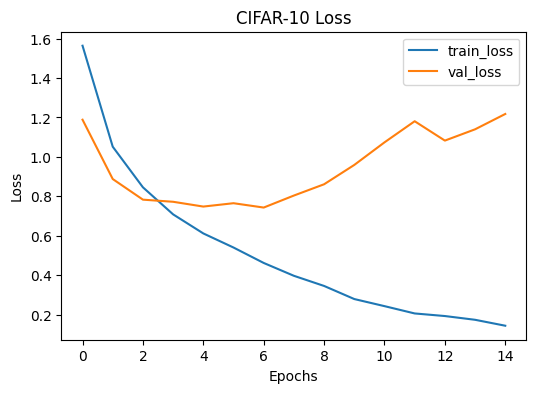

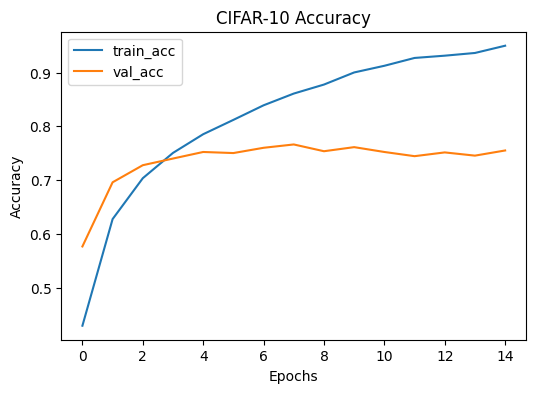

In [20]:
plot_history(c10_history, title_prefix="CIFAR-10")

## ✅ Evaluación final: Acuracy y Matriz de confusión

Una vez entrenado el modelo, se evalúa su desempeño sobre el conjunto de **test** mediante:

- **Predicciones**: se obtienen las probabilidades con `model.predict` y se convierten a clases con `argmax`.  
- **Matriz de confusión (`confusion_matrix`)**: muestra cómo se distribuyen los aciertos y errores por clase.  

Este análisis permite identificar en qué clases el modelo funciona mejor y en cuáles presenta mayores confusiones.

In [21]:
# === Evaluación en train y test ===
train_loss, train_acc = c10_model.evaluate(c10_x_train, c10_y_train_cat, verbose=0)
test_loss, test_acc   = c10_model.evaluate(c10_x_test,  c10_y_test_cat,  verbose=0)

print("** CNN [CIFAR-10] **")
print(f"➡️ Train Accuracy: {train_acc:.4f}")
print(f"➡️ Test  Accuracy: {test_acc:.4f}")

# === Predicciones ===
c10_pred_probs = c10_model.predict(c10_x_test, verbose=0)
c10_y_pred = np.argmax(c10_pred_probs, axis=1)
c10_y_true = np.squeeze(c10_y_test)


** CNN [CIFAR-10] **
➡️ Train Accuracy: 0.8400
➡️ Test  Accuracy: 0.7486


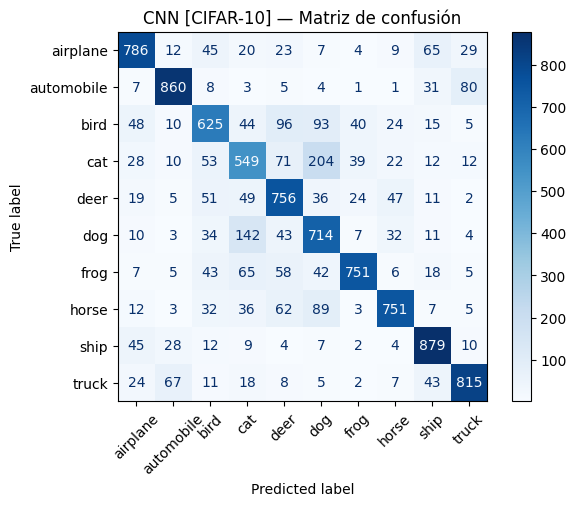

In [22]:
# === Matriz de confusión ===
cm = confusion_matrix(c10_y_true, c10_y_pred)

# === Visualización con ConfusionMatrixDisplay ===
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names_c10)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("CNN [CIFAR-10] — Matriz de confusión")
plt.show()


## ⚠️ Overfitting en la CNN sobre CIFAR-10

Al entrenar el modelo observamos:

- 📉 La `train_loss` disminuye de forma continua → el modelo aprende cada vez mejor los datos de entrenamiento.
- ✅ Durante las primeras épocas también disminuye la `val_loss`.
- ⚠️ Aproximadamente a partir de la **época 6**, la `val_loss` deja de mejorar y comienza a aumentar.
- 🔼 Mientras la `train_loss` sigue bajando, la `val_loss` empeora → aparece **overfitting**.
- ⛔ Gracias a `EarlyStopping`, el entrenamiento se detiene antes de llegar a las 25 épocas.

---

### ❓ ¿Qué está pasando?

- El modelo comienza a **ajustarse demasiado a los datos de entrenamiento**.
- Sigue reduciendo el error sobre `train`, pero empeora su desempeño sobre datos no vistos.
- La mejor versión del modelo corresponde aproximadamente al punto donde la `val_loss` alcanza su mínimo.

---

### 🔧 ¿Cómo lo controlamos?

- Usamos **Early Stopping** para detener el entrenamiento cuando `val_loss` deja de mejorar.
- `patience=8` permite esperar hasta 8 épocas por si vuelve a aparecer una mejora.
- `restore_best_weights=True` recupera automáticamente los pesos correspondientes a la mejor `val_loss`.

### 🚀 ¿Cómo lo mejoramos?

- Incorporar **Dropout** para apagar aleatoriamente algunas neuronas durante el entrenamiento y hacer al modelo más robusto.
- Agregar **regularización** para penalizar soluciones demasiado complejas y reducir el overfitting.
- Incorporar **Batch Normalization** para estabilizar las activaciones y facilitar el entrenamiento de la red.
- Aplicar **Data Augmentation** para aumentar la variedad de imágenes de entrenamiento y mejorar la generalización.

➡️ El entrenamiento no se detiene porque el modelo haya fallado, sino porque **ya no está mejorando su capacidad de generalización**.

***
# 🎯 Práctica 3: Mejorando la CNN con regularización y normalización

📊 **Dataset**  
Continuamos utilizando el dataset **CIFAR-10**, con imágenes de `32×32×3` en 10 clases.

🎯 **Objetivo**  
Comparar el desempeño de una CNN básica contra una versión mejorada que incorpora:  
- **Batch Normalization** → estabiliza y acelera el aprendizaje.  
- **Dropout** → reduce el riesgo de sobreajuste (*overfitting*).  

✅ **Evaluación**  
Se utilizarán métricas como **Accuracy** y **matriz de confusión** para analizar los resultados.  


## 🧩 Arquitectura CNN mejorada para CIFAR-10

En esta versión se mejora la red convolucional básica incorporando dos técnicas clave:  

- **Batch Normalization (BN)**:  
  Normaliza la salida de cada capa para estabilizar la distribución de activaciones y acelerar el aprendizaje.  

- **Dropout (DO)**:  
  Apaga aleatoriamente un porcentaje de neuronas durante el entrenamiento para reducir el riesgo de *overfitting*.  

### 🔨 Estructura del modelo
- **Entrada**: imágenes de `32×32×3`.  

- **Bloques convolucionales**:  
  - `Conv2D(32)` → `BN` → `ReLU` → `Conv2D(32)` → `BN` → `ReLU` → `MaxPooling` → `Dropout(0.25)`  
  - `Conv2D(64)` → `BN` → `ReLU` → `Conv2D(64)` → `BN` → `ReLU` → `MaxPooling` → `Dropout(0.3)`  
  - `Conv2D(128)` → `BN` → `ReLU` → `MaxPooling` → `Dropout(0.4)`  

- **Clasificación final**:  
  - `Flatten` → `Dense(256)` → `BN` → `ReLU` → `Dropout(0.5)` → `Dense(10, Softmax)`  

### ⚙️ Configuración de entrenamiento
- Optimizador: **Adam (lr=1e-3)**  
- Pérdida: **Categorical Crossentropy**  
- Métrica: **Accuracy**  

📌 Con esta arquitectura se espera un entrenamiento más estable y un mejor desempeño en general frente al modelo base.

In [23]:
# Arquitectura CNN (CIFAR-10) — con BatchNorm y Dropout
input_shape = (32, 32, 3)
num_classes = 10

c10_model_bn_do = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, 3, padding='same'), 
    layers.BatchNormalization(), 
    layers.ReLU(),
    layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

c10_model_bn_do.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c10_model_bn_do.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

## ⏱️ Entrenamiento del modelo mejorado

- Se entrena la **CNN con BatchNorm y Dropout** sobre CIFAR-10.  
- Se utiliza **EarlyStopping** para detener el entrenamiento si `val_loss` no mejora en 8 epochs, restaurando los mejores pesos.  
- Se grafican las curvas de *loss* y *accuracy* con `plot_history` para analizar el desempeño en entrenamiento y validación.

In [24]:
# ⏱️ Entrenamiento del modelo mejorado (BN + Dropout)

# Callback: EarlyStopping
early = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# Entrenamiento con validación
history_c10_bn_do = c10_model_bn_do.fit(
    c10_x_train, c10_y_train_cat,
    validation_split=0.1,
    epochs=40,      
    batch_size=128,
    callbacks=[early],
    verbose=1
)

Epoch 1/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 173ms/step - accuracy: 0.4228 - loss: 1.6303 - val_accuracy: 0.2042 - val_loss: 2.7801
Epoch 2/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 65s 184ms/step - accuracy: 0.5790 - loss: 1.1728 - val_accuracy: 0.6200 - val_loss: 1.0826
Epoch 3/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 177ms/step - accuracy: 0.6407 - loss: 1.0067 - val_accuracy: 0.6776 - val_loss: 0.9121
Epoch 4/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 62s 175ms/step - accuracy: 0.6808 - loss: 0.8996 - val_accuracy: 0.6920 - val_loss: 0.8708
Epoch 5/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 174ms/step - accuracy: 0.7048 - loss: 0.8299 - val_accuracy: 0.7314 - val_loss: 0.7481
Epoch 6/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.7244 - loss: 0.7802 - val_accuracy: 0.7454 - val_loss: 0.7455
Epoch 7/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.7397 - loss: 0.7412 - val_accuracy: 0.7712 - val_loss: 0.6439
Epoch 8/40
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 175ms/step - accuracy: 0.7539 - loss: 0

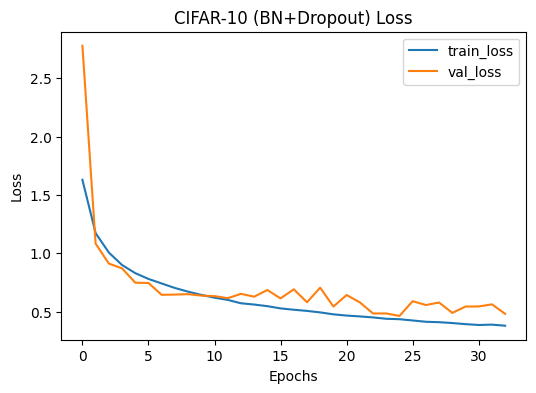

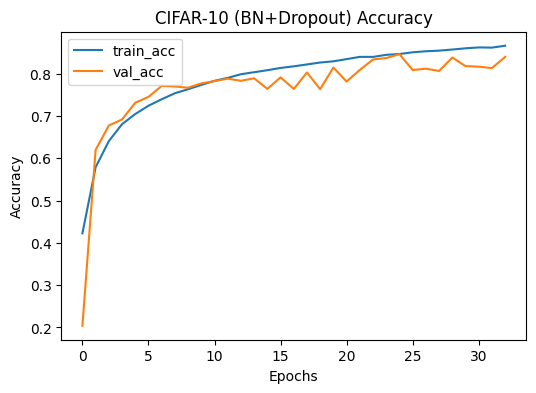

In [25]:
plot_history(history_c10_bn_do, title_prefix="CIFAR-10 (BN+Dropout)")

## ✅ Evaluación del modelo mejorado

- Se evalúa la CNN (BN + Dropout) sobre el **conjunto de training** y sobre el **conjunto de testeo**.  
- Se obtienen métricas **Train Accuracy** y **Test Accuracy**.  
- Se generan la **Matriz de confusión** para analizar aciertos y errores por clase.  

In [26]:

# === Evaluación en train y test ===
train_loss, train_acc = c10_model_bn_do.evaluate(c10_x_train, c10_y_train_cat, verbose=0)
test_loss, test_acc   = c10_model_bn_do.evaluate(c10_x_test,  c10_y_test_cat,  verbose=0)

print("** CNN (BN+DO) [CIFAR-10] **")
print(f"➡️ Train Accuracy: {train_acc:.4f}")
print(f"➡️ Test  Accuracy: {test_acc:.4f}")

# === Predicciones ===
c10_pred_probs = c10_model_bn_do.predict(c10_x_test, verbose=0)
c10_y_pred = np.argmax(c10_pred_probs, axis=1)
c10_y_true = np.squeeze(c10_y_test)


** CNN (BN+DO) [CIFAR-10] **
➡️ Train Accuracy: 0.9060
➡️ Test  Accuracy: 0.8307


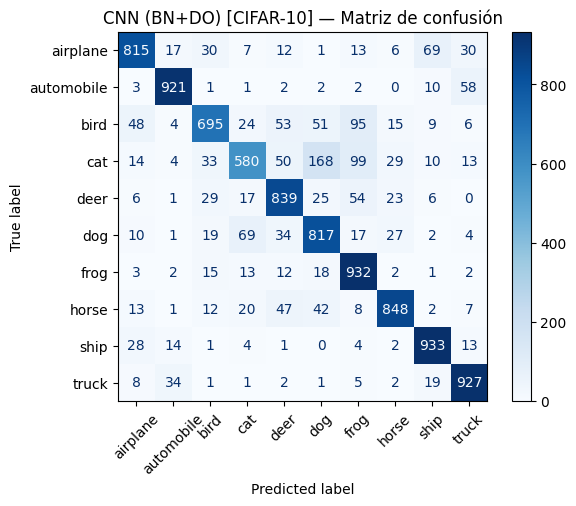

In [27]:
# === Matriz de confusión ===
cm = confusion_matrix(c10_y_true, c10_y_pred)

# === Visualización con ConfusionMatrixDisplay ===
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names_c10)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("CNN (BN+DO) [CIFAR-10] — Matriz de confusión")
plt.show()


## ✅ Análisis del modelo con Batch Normalization + Dropout

Al observar conjuntamente las curvas de `loss` y `accuracy`:

- 📉 La `train_loss` disminuye de forma sostenida durante todo el entrenamiento.
- 📉 La `val_loss` también baja en las primeras épocas y luego se mantiene relativamente estable, con algunas oscilaciones.
- 📈 La `train_accuracy` aumenta progresivamente.
- 📈 La `val_accuracy` mejora rápidamente y luego se estabiliza en valores cercanos al **82–84%**.
- ✅ La diferencia entre entrenamiento y validación se mantiene relativamente pequeña.
- ✅ Ya no se observa el aumento sostenido de `val_loss` que aparecía en el modelo anterior.

---

### 💡 Interpretación

El modelo continúa aprendiendo sobre los datos de entrenamiento, pero al mismo tiempo mantiene un buen desempeño sobre los datos de validación.

Las pequeñas oscilaciones en `val_loss` y `val_accuracy` son normales y no indican un overfitting severo.

La incorporación de:

- **Batch Normalization** ayuda a estabilizar las activaciones y facilita el entrenamiento.
- **Dropout** ayuda a reducir el overfitting apagando aleatoriamente algunas neuronas durante el entrenamiento.

➡️ En conjunto, las curvas muestran un entrenamiento **más estable y una mejor capacidad de generalización** que en el modelo anterior.

***
## 🎯 Práctica 4: Data Augmentation en CIFAR-10

En esta práctica vamos a aplicar **Data Augmentation** en CIFAR-10 para aumentar la diversidad de los datos de entrenamiento y evaluar su impacto en el desempeño del modelo.  

⚙️ **Estrategia**  
- Se implementan transformaciones como **flips**, **rotaciones**, **zooms** y **traslaciones**.  
- El modelo CNN mejorado (BatchNorm + Dropout) se entrena sobre el dataset aumentado.  
- Se comparan resultados contra el entrenamiento sin *augmentation*, usando **Accuracy** y **matriz de confusión**.  

✅ Con esta práctica se busca observar cómo el *Data Augmentation* contribuye a mejorar la **generalización** del modelo.

## 🌱 Data Augmentation

Se define un bloque de **Data Augmentation** utilizando capas de preprocesamiento de Keras.  
Este bloque se aplica durante el entrenamiento para generar nuevas versiones de las imágenes, aumentando así la diversidad del dataset:  

- `RandomFlip("horizontal")` → voltea imágenes horizontalmente.  
- `RandomRotation(0.08)` → rota las imágenes hasta un 8%.  
- `RandomZoom(0.10)` → aplica zoom aleatorio de hasta un 10%.  
- `RandomTranslation(0.10, 0.10)` → desplaza imágenes horizontal y verticalmente hasta un 10%.  

📌 Estas transformaciones permiten que el modelo sea más **robusto** y **generalice mejor** al evitar sobreajuste.

**❗Importante: Data Augmentation no aumenta físicamente el tamaño del dataset: genera nuevas variantes aleatorias de las imágenes en cada época, haciendo que el modelo vea ejemplos distintos durante el entrenamiento.**

In [28]:
# ============================
# 1) Data Augmentation
# ============================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
], name="data_augmentation")


## ⚙️ Pipeline de entrenamiento con Data Augmentation

- Se construye un `Dataset` de TensorFlow que aplica las transformaciones de **Data Augmentation** en cada batch (`training=True`).  
- Se utiliza `shuffle`, `batch` y `prefetch` para optimizar el flujo de datos.  
- Para la **validación**, se emplea el conjunto de test sin augmentación.  

In [29]:
# ============================
# 2) Pipeline de entrenamiento con augment
# ============================
AUTOTUNE = tf.data.AUTOTUNE
batch_size = 128

train_ds_aug = (
    tf.data.Dataset.from_tensor_slices((c10_x_train, c10_y_train_cat))
    .shuffle(50_000)
    .batch(batch_size)
    # Importante: llamar al aug con training=True para que aplique las trafos
    .map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Para validar, usamos el set de test (sin augment)
val_data = (c10_x_test, c10_y_test_cat)

## ⏱️ Entrenamiento con EarlyStopping

- Se entrena la CNN (BN + Dropout) sobre el **dataset aumentado**.  
- Se aplica **EarlyStopping**: detiene el entrenamiento si `val_loss` no mejora en 8 epochs y restaura los mejores pesos.  
- Se registran las curvas de *loss* y *accuracy* con `plot_history` para analizar el efecto del **Data Augmentation**.  

In [30]:
# Arquitectura CNN (CIFAR-10) — con BatchNorm y Dropout
input_shape = (32, 32, 3)
num_classes = 10

c10_model_bn_do_da = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, 3, padding='same'), 
    layers.BatchNormalization(), 
    layers.ReLU(),
    layers.Conv2D(32, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.Conv2D(64, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same'), layers.BatchNormalization(), layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256), layers.BatchNormalization(), layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

c10_model_bn_do_da.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c10_model_bn_do_da.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [31]:
# ============================
# 3) Entrenamiento con EarlyStopping
# ============================
early = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

history_c10_aug = c10_model_bn_do_da.fit(
    train_ds_aug,
    validation_data=val_data,
    epochs=40,
    callbacks=[early],
    verbose=1
)

Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 79s 198ms/step - accuracy: 0.3611 - loss: 1.7995 - val_accuracy: 0.2753 - val_loss: 2.2551
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 205ms/step - accuracy: 0.4812 - loss: 1.4330 - val_accuracy: 0.4815 - val_loss: 1.4375
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 214ms/step - accuracy: 0.5355 - loss: 1.2925 - val_accuracy: 0.5018 - val_loss: 1.4458
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 216ms/step - accuracy: 0.5667 - loss: 1.2076 - val_accuracy: 0.5677 - val_loss: 1.2081
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 217ms/step - accuracy: 0.5956 - loss: 1.1367 - val_accuracy: 0.5773 - val_loss: 1.2255
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 217ms/step - accuracy: 0.6125 - loss: 1.0914 - val_accuracy: 0.6102 - val_loss: 1.1179
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 217ms/step - accuracy: 0.6285 - loss: 1.0466 - val_accuracy: 0.6612 - val_loss: 0.9730
Epoch 8/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 85s 217ms/step - accuracy: 0.6478 - loss: 1

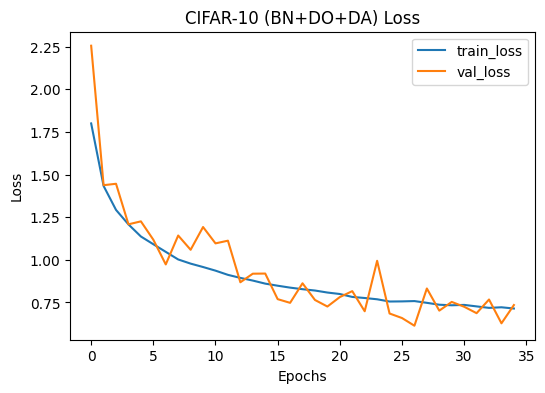

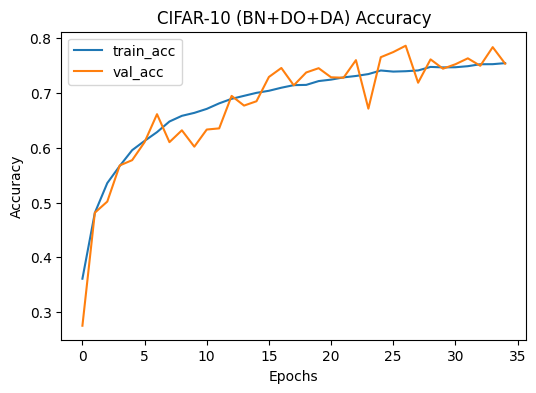

In [32]:
plot_history(history_c10_aug, title_prefix="CIFAR-10 (BN+DO+DA)")

## ✅ Evaluación del impacto del Data Augmentation

- Se evalúa el modelo CNN (BN + Dropout + Augmentation) en el **set de entrenamiento** y en el **set de testeo**.  
- Se reportan métricas: **Train Accuracy** y **Test Accuracy**.  
- Se genera la **Matriz de confusión** → analiza aciertos y errores por clase.  

In [33]:

# === Evaluación en train y test ===
train_loss, train_acc = c10_model_bn_do_da.evaluate(c10_x_train, c10_y_train_cat, verbose=0)
test_loss, test_acc   = c10_model_bn_do_da.evaluate(c10_x_test,  c10_y_test_cat,  verbose=0)

print("** CNN (BN+DO+DA) [CIFAR-10]**")
print(f"➡️ Train Accuracy: {train_acc:.4f}")
print(f"➡️ Test  Accuracy: {test_acc:.4f}")

# === Predicciones ===
c10_pred_probs = c10_model_bn_do_da.predict(c10_x_test, verbose=0)
c10_y_pred = np.argmax(c10_pred_probs, axis=1)
c10_y_true = np.squeeze(c10_y_test)


** CNN (BN+DO+DA) [CIFAR-10]**
➡️ Train Accuracy: 0.8039
➡️ Test  Accuracy: 0.7861


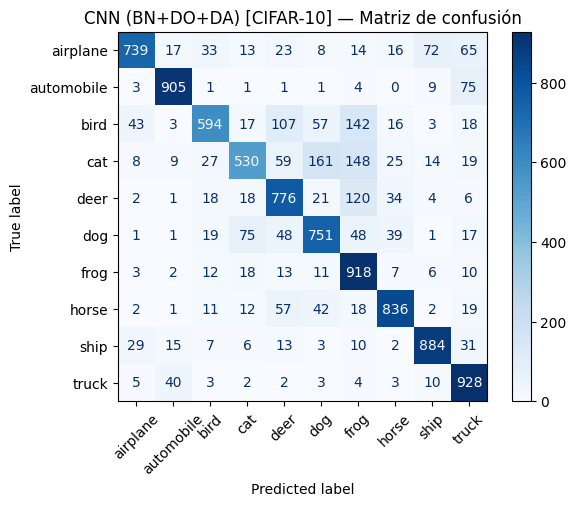

In [34]:
# === Matriz de confusión ===
cm = confusion_matrix(c10_y_true, c10_y_pred)

# === Visualización con ConfusionMatrixDisplay ===
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names_c10)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("CNN (BN+DO+DA) [CIFAR-10] — Matriz de confusión")
plt.show()

## ✅ Análisis del modelo con Batch Normalization + Dropout + Data Augmentation

Al incorporar **Data Augmentation** al modelo anterior observamos:

- 📉 La `train_loss` disminuye de forma sostenida durante el entrenamiento.
- 📉 La `val_loss` también muestra una tendencia descendente, aunque presenta mayores oscilaciones.
- 📈 La `train_accuracy` aumenta progresivamente hasta valores cercanos al **76%**.
- 🔄 La `val_accuracy` fluctúa más entre épocas, pero se mantiene en valores similares a los de entrenamiento.
- ✅ La diferencia entre entrenamiento y validación es pequeña, lo que indica que el overfitting está bien controlado.

---

### 💡 ¿Qué está pasando?

Con **Data Augmentation**, el modelo recibe versiones modificadas de las imágenes originales durante cada época.

Esto hace que el conjunto de entrenamiento sea más difícil y variado, por lo que:

- el `accuracy` de entrenamiento puede ser menor;
- la `loss` de entrenamiento puede ser mayor;
- al modelo le resulta más difícil memorizar los ejemplos;
- mejora la capacidad de generalizar a imágenes nuevas.

---

### 📌 Importante

Un menor `train_accuracy` no significa necesariamente que el modelo haya empeorado.

➡️ En este caso, el **Data Augmentation está funcionando como una forma de regularización**, haciendo el entrenamiento más exigente pero reduciendo la diferencia entre train y validation.

**Data Augmentation no garantiza automáticamente mejores métricas.**  
Es una técnica de regularización: Data Augmentation regulariza aumentando la variedad de ejemplos que ve el modelo. 

PERO si las transformaciones son demasiado agresivas, podemos reducir el overfitting pero también dificultar demasiado el aprendizaje.

Augmentation demasiado débil
→ casi no aporta

Augmentation adecuado
→ reduce overfitting y mejora generalización ✅

Augmentation demasiado fuerte
→ dificulta demasiado el aprendizaje
→ puede aparecer underfitting

➡️ En este caso, con Data Augmentation la diferencia entre `train` y `validation` se redujo, pero la `loss` general quedó más alta.

***
## 🌐 Bonus Track: Transfer Learning con MobileNetV2 en CIFAR-10

En esta práctica exploraremos cómo aprovechar un modelo preentrenado en **ImageNet** para mejorar el desempeño en el dataset **CIFAR-10** usando **Transfer Learning**.  

✅ Con esta práctica se ilustra cómo el **Transfer Learning** permite aprovechar redes ya entrenadas en grandes datasets, logrando buenos resultados con menos tiempo de entrenamiento y menor riesgo de *overfitting*.  
### 📥 1) Preparación de datos

CIFAR-10 tiene imágenes de `32×32`, pero MobileNetV2 espera entradas más grandes.  
Por eso, redimensionamos las imágenes a `96×96` y aplicamos el preprocesamiento adecuado (`preprocess_input`) para escalar los píxeles a `[-1,1]`.  

In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

IMG_SIZE   = 96   # más grande que 32x32
BATCH_SIZE = 128
AUTOTUNE   = tf.data.AUTOTUNE

def prep(x, y):
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    x = preprocess_input(x * 255.0)  # MobileNetV2 espera entrada en [-1,1]
    return x, y

train_ds = (tf.data.Dataset.from_tensor_slices((c10_x_train, c10_y_train_cat))
            .shuffle(50_000).map(prep, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset.from_tensor_slices((c10_x_test, c10_y_test_cat))
            .map(prep, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

### 🌱 2) Data Augmentation (opcional)

Para mejorar la generalización, podemos aplicar pequeñas transformaciones como flips y rotaciones durante el entrenamiento.  

In [36]:
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
], name="augment")

### 🧩 3) Definición del modelo con MobileNetV2

- Usamos **MobileNetV2** preentrenada en ImageNet como **extractor de características**.
    - weights="imagenet" → usás los pesos pre-entrenados en ImageNet (1.2M imágenes, 1000 clases).
    - include_top=False → no cargás la parte final (clasificador de 1000 clases). Solo la base convolucional que extrae características.
    - input_shape=(IMG_SIZE, IMG_SIZE, 3) → tamaño de las imágenes que va a recibir (alto, ancho, 3 canales RGB).
- Congelamos sus pesos en una primera etapa → base.trainable = False
- Añadimos un **clasificador final** adaptado a las 10 clases de CIFAR-10.  

In [37]:
base = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False  # congelamos pesos

tl_model = keras.Sequential([
    augment,                        # data augmentation
    base,                           # MobileNetV2 como extractor de features
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

### ⚙️ 4) Compilación y entrenamiento inicial

Entrenamos **solo la parte superior (clasificador)**, manteniendo la base convolucional congelada.  

In [38]:
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

hist_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early],
    verbose=1
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 103s 260ms/step - accuracy: 0.7259 - loss: 0.8123 - val_accuracy: 0.8348 - val_loss: 0.4744
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 102s 260ms/step - accuracy: 0.8015 - loss: 0.5796 - val_accuracy: 0.8433 - val_loss: 0.4591
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 103s 262ms/step - accuracy: 0.8132 - loss: 0.5439 - val_accuracy: 0.8509 - val_loss: 0.4381
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 103s 263ms/step - accuracy: 0.8166 - loss: 0.5331 - val_accuracy: 0.8542 - val_loss: 0.4175
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 103s 262ms/step - accuracy: 0.8197 - loss: 0.5222 - val_accuracy: 0.8464 - val_loss: 0.4379
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 103s 264ms/step - accuracy: 0.8216 - loss: 0.5120 - val_accuracy: 0.8475 - val_loss: 0.4341
Epoch 9/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 104s 265ms/step - accuracy: 0.8257 - loss: 0.5089 - val_accuracy: 0.8463 - val_loss: 0.4369
Epoch 10/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 104s 266ms/step - accuracy: 0.8258 

### 🔧 5) Fine-tuning (opcional)

Descongelamos las últimas capas convolucionales del modelo base  y entrenamos con una tasa de aprendizaje más baja para ajustar los pesos.  

In [46]:
base = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = True

tl_model_2 = keras.Sequential([
    augment,                        # data augmentation
    base,                           # MobileNetV2 como extractor de features
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
])

for layer in base.layers[:-20]:  # descongelamos solo las últimas capas
    layer.trainable = False

tl_model_2.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # LR bajo para no dañar los pesos
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

hist_ft = tl_model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early],
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 337ms/step - accuracy: 0.7756 - loss: 0.6649 - val_accuracy: 0.8095 - val_loss: 0.6570
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 133s 339ms/step - accuracy: 0.8617 - loss: 0.3988 - val_accuracy: 0.8477 - val_loss: 0.4904
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 134s 343ms/step - accuracy: 0.8862 - loss: 0.3274 - val_accuracy: 0.8597 - val_loss: 0.4395
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 359ms/step - accuracy: 0.9037 - loss: 0.2755 - val_accuracy: 0.8749 - val_loss: 0.3789
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 345ms/step - accuracy: 0.9156 - loss: 0.2401 - val_accuracy: 0.8836 - val_loss: 0.3555
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 346ms/step - accuracy: 0.9272 - loss: 0.2101 - val_accuracy: 0.8595 - val_loss: 0.4674


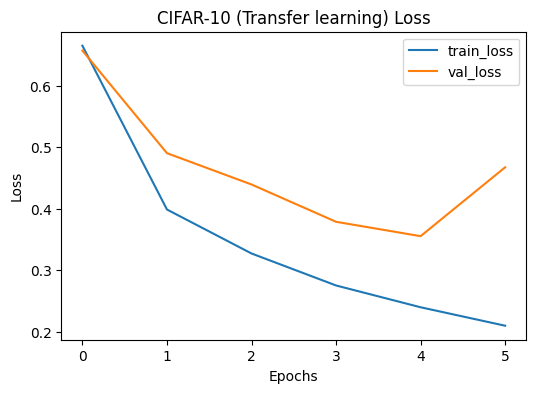

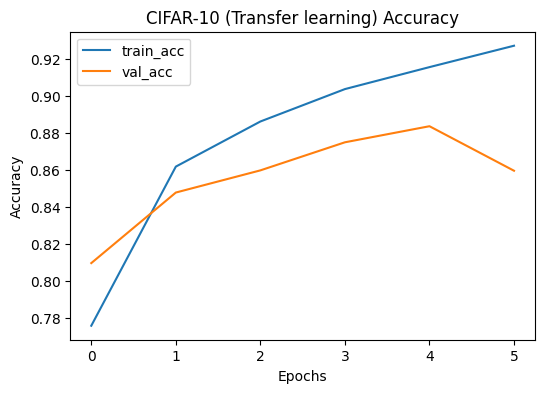

In [47]:
plot_history(hist_ft, title_prefix="CIFAR-10 (Transfer learning)")

### ✅ 6) Evaluación del modelo

Finalmente, evaluamos el desempeño en el **set de test** y analizamos los resultados con **Accuracy** y **matriz de confusión** 

In [48]:
# === Evaluación en train y test ===
train_loss, train_acc = tl_model_2.evaluate(train_ds, verbose=0)

test_ds = (tf.data.Dataset.from_tensor_slices((c10_x_test, c10_y_test_cat))
           .map(prep, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

test_loss, test_acc   = tl_model_2.evaluate(test_ds,  verbose=0)

print("** Transfer Learning [CIFAR-10]**")
print(f"➡️ Train Accuracy: {train_acc:.4f}")
print(f"➡️ Test  Accuracy: {test_acc:.4f}")


** Transfer Learning [CIFAR-10]**
➡️ Train Accuracy: 0.8198
➡️ Test  Accuracy: 0.8095


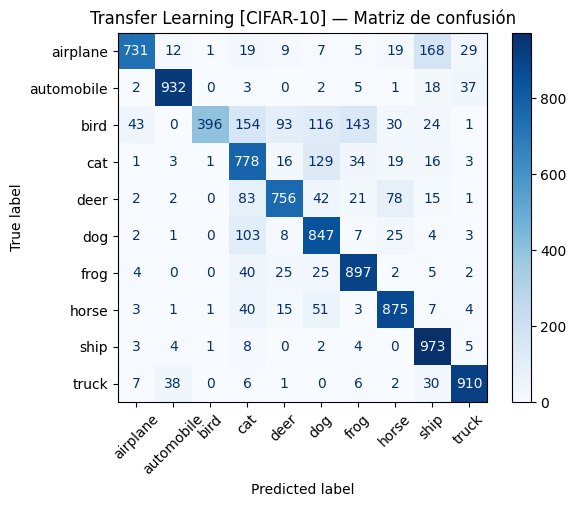

In [49]:
# === Predicciones ===
c10_pred_probs = tl_model_2.predict(test_ds, verbose=0)
c10_y_pred = np.argmax(c10_pred_probs, axis=1)
c10_y_true = np.squeeze(c10_y_test)

# === Matriz de confusión ===
cm = confusion_matrix(c10_y_true, c10_y_pred)

# === Visualización con ConfusionMatrixDisplay ===
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names_c10)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Transfer Learning [CIFAR-10] — Matriz de confusión")
plt.show()
